# E003 — Run the detector on every frame of the video

**What we did so far:** we tested detectors on only 15 hand-labelled frames.

**What this notebook does:** it runs the detectors on all 1303 frames of the video. Three things depend on this:

1. **Crowd masks.** The camera-motion estimate must ignore people. If it doesn't, the slowly moving crowd fools it into thinking the camera moved.
2. **Count stability.** We check whether the number of people jumps around from one frame to the next, or stays smooth like a real crowd.
3. **The base for Phase 1.** The saved boxes feed every later step.

**Before any heavy work:** we first check the video itself. Is it the right size, does it have the expected number of frames, and is frame number 93 in the video really the photo we labelled as frame 93?

## Cell 2 — Set up the notebook and find the video

**What this cell does, in simple words:**
1. **Downloads our project code** from GitHub, so the notebook can use the functions we already wrote (reading annotations, tiling, scoring).
2. **Installs ultralytics**, the library that runs the YOLO detectors.
3. **Looks for the video file** (`14931663_1080_1920_60fps.mp4`) in the project folder and in Kaggle's input data.

**What you should see:**
- `tiling.py present: True`, meaning the code downloaded correctly.
- `videos found:` followed by the video's path.

**If it says `NONE`:** the video isn't in Kaggle yet. Click Add Input, then Upload, choose the `.mp4`, and run this cell again.

In [1]:
# ===== Cell 2: clone repo, install ultralytics, locate the video =====
import os, subprocess, glob, sys
from pathlib import Path

REPO_URL = "https://github.com/SagarInspires/crowd-intelligence.git"
REPO_DIR = Path("/kaggle/working/crowd-intelligence")

def sync_repo():
    """Clone the repo if absent, otherwise pull; put it on sys.path so `src.*` imports work."""
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--rebase"], check=True)
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))

def find_video(name_hint="14931663"):
    """Search the repo and Kaggle inputs for .mp4 files; return the sorted unique paths."""
    hits = []
    for r in (str(REPO_DIR), "/kaggle/input"):
        hits += glob.glob(f"{r}/**/*.mp4", recursive=True)
    return sorted(set(hits))

sync_repo()
os.system("pip install -q ultralytics")
print("tiling.py present:", (REPO_DIR / "src/models/tiling.py").exists())
videos = find_video()
print("videos found:", videos if videos else "NONE  -> add the mp4 as a Kaggle Dataset (Add Input -> Upload)")

Cloning into '/kaggle/working/crowd-intelligence'...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 3.5 MB/s eta 0:00:00
tiling.py present: True
videos found: ['/kaggle/input/datasets/sagarupsc/day1video/14931663_1080_1920_60fps.mp4']


In [2]:
# ===== Cell 3: probe the video and verify annotation frame numbering =====
import cv2, numpy as np
from src.data.via import frame_id_from_name

def pick_video(hits, hint="14931663"):
    """Choose the video: exactly one file matching the hint, else the only mp4; otherwise stop."""
    pref = [h for h in hits if hint in Path(h).name]
    pool = pref if pref else hits
    assert len(pool) == 1, f"expected exactly one video, found {len(pool)}: {pool}"
    return Path(pool[0])

def probe_video(path):
    """Return fps, reported frame count, width, height, and the ACTUAL decoded frame count."""
    cap = cv2.VideoCapture(str(path))
    assert cap.isOpened(), "cannot open video"
    info = dict(fps=cap.get(cv2.CAP_PROP_FPS), n_reported=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
                W=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), H=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    n = 0
    while cap.grab():                       # decode-only pass, counts real frames
        n += 1
    cap.release()
    info["n_decoded"] = n
    return info

def read_frames(path, wanted):
    """Sequentially read the frames whose indices are in `wanted` (avoids inaccurate seeking)."""
    wanted, out, cap, i = set(wanted), {}, cv2.VideoCapture(str(path)), 0
    while cap.isOpened() and len(out) < len(wanted):
        ok, fr = cap.read()
        if not ok:
            break
        if i in wanted:
            out[i] = fr
        i += 1
    cap.release()
    return out

def check_alignment(video_frames, image_dir, id_fn):
    """Compare each annotated photo with the video frame of the same index; a small mean
    absolute difference means the annotation frame numbering matches the video."""
    rows = []
    for p in sorted(Path(image_dir).glob("*")):
        if p.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
        fid = id_fn(p.name)
        img = cv2.imread(str(p))
        vf = video_frames[fid]
        if img.shape != vf.shape:
            img = cv2.resize(img, (vf.shape[1], vf.shape[0]))
        rows.append((fid, float(np.abs(img.astype(np.int16) - vf.astype(np.int16)).mean())))
    return rows

VIDEO = pick_video(videos)
info = probe_video(VIDEO)
print("video:", VIDEO.name, "|", info)
assert (info["H"], info["W"]) == (1920, 1080), "unexpected frame size (rotation metadata?)"

IMG_DIR = REPO_DIR / "data/your_video/annotated_frames"
want = [frame_id_from_name(p.name) for p in IMG_DIR.glob("*")
        if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
vf = read_frames(VIDEO, want)
for fid, d in check_alignment(vf, IMG_DIR, frame_id_from_name):
    print(f"frame {fid:5d}  mean |photo - video frame| = {d:6.2f}")

video: 14931663_1080_1920_60fps.mp4 | {'fps': 59.94005994005994, 'n_reported': 1303, 'W': 1080, 'H': 1920, 'n_decoded': 1303}
frame     0  mean |photo - video frame| =   1.51
frame    93  mean |photo - video frame| =   1.50
frame   186  mean |photo - video frame| =   1.47
frame   279  mean |photo - video frame| =   1.36
frame   372  mean |photo - video frame| =   1.40
frame   465  mean |photo - video frame| =   1.40
frame   558  mean |photo - video frame| =   1.40
frame   651  mean |photo - video frame| =   1.38
frame   744  mean |photo - video frame| =   1.40
frame   837  mean |photo - video frame| =   1.40
frame   930  mean |photo - video frame| =   1.41
frame  1023  mean |photo - video frame| =   1.42
frame  1116  mean |photo - video frame| =   1.41
frame  1209  mean |photo - video frame| =   1.43
frame  1302  mean |photo - video frame| =   1.41


## Cell 4 — Run YOLOv8x on the video (first 30 frames as a test)

**In simple words:** we play the video frame by frame and ask YOLOv8x "where are the people?". For every frame we save every box it proposes together with its confidence score. We keep even very unsure boxes, and choose the cutoff later. That way we don't have to re-run the detector if the cutoff changes.

**Why YOLOv8x here:** in E002 it gave the best head counts (MAE 18.7), and it runs on the whole frame, so it is cheap.

**Why it saves in chunks of 100 frames:** Kaggle sessions can stop. If that happens, running the cell again skips the finished chunks and continues from where it stopped.

**How to use it:**
1. First run with `LIMIT = 30`. This is a quick test, and its files are tagged `_smoke` so they can't be confused with the real run.
2. If it works, set `LIMIT = None` and run again. That is the real run over all 1303 frames.

**What to look at in the output:** how many boxes per frame there are at a cutoff of 0.005 (this should be roughly the size of the crowd, about 400–500 at first glance), and how many seconds one frame takes.

In [3]:
# ===== Cell 4: YOLOv8x whole-frame detection on the video (resumable, shard-saved) =====
import time
import numpy as np
import cv2
import torch
from pathlib import Path
from ultralytics import YOLO

OUT3 = Path("/kaggle/working/outputs/e003")
OUT3.mkdir(parents=True, exist_ok=True)

def sync():
    """Wait for the GPU to finish, so timings measure real work (no-op without a GPU)."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def detect_full(model, img, imgsz=1920, conf=0.001, max_det=3000):
    """Whole-frame person detection (same call as the E002 baseline: default NMS/IoU settings).
    Returns (boxes xyxy float32, scores float32) in full-image pixels."""
    r = model.predict(img, imgsz=imgsz, classes=[0], conf=conf, max_det=max_det, verbose=False)[0]
    return r.boxes.xyxy.cpu().numpy().astype(np.float32), r.boxes.conf.cpu().numpy().astype(np.float32)

def flush(buf, path):
    """Write one shard to disk and empty the buffer."""
    np.savez_compressed(path, frame_ids=np.array(buf["ids"], np.int32), counts=np.array(buf["n"], np.int32),
                        boxes=np.concatenate(buf["b"]) if buf["b"] else np.zeros((0, 4), np.float32),
                        scores=np.concatenate(buf["s"]) if buf["s"] else np.zeros(0, np.float32),
                        secs=np.array(buf["t"], np.float32))
    for k in buf:
        buf[k].clear()

def run_video(video, det_fn, tag, out_dir, limit=None, shard=100):
    """Run `det_fn(img) -> (boxes, scores)` on every frame of `video`, in order.
    Results are saved every `shard` frames as out_dir/{tag}_part{k:03d}.npz, so an
    interrupted session resumes by skipping finished shards. Saved per shard: frame_ids,
    counts (boxes per frame), boxes, scores, secs (seconds per frame, GPU-synchronised)."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video))
    buf = dict(ids=[], n=[], b=[], s=[], t=[]); i = 0
    while True:
        ok, img = cap.read()                                     # frames are read strictly in order
        if not ok or (limit is not None and i >= limit):
            break
        f = out_dir / f"{tag}_part{i // shard:03d}.npz"
        if not f.exists():                                       # detect only in unfinished shards
            sync(); t0 = time.perf_counter()
            b, s = det_fn(img)
            sync(); dt = time.perf_counter() - t0
            buf["ids"].append(i); buf["n"].append(len(s)); buf["b"].append(b)
            buf["s"].append(s); buf["t"].append(dt)
        i += 1
        if buf["ids"] and i % shard == 0:                        # a full shard is done -> save it
            flush(buf, out_dir / f"{tag}_part{(i - 1) // shard:03d}.npz")
    if buf["ids"]:                                               # save the last partial shard
        flush(buf, out_dir / f"{tag}_part{(i - 1) // shard:03d}.npz")
    cap.release()
    return i

def load_run(tag, out_dir):
    """Load all shards of a run -> dict(frame_ids, counts, boxes, scores, secs)."""
    parts = sorted(Path(out_dir).glob(f"{tag}_part*.npz"))
    assert parts, f"no shards for {tag}"
    z = [np.load(p) for p in parts]
    return {k: np.concatenate([a[k] for a in z]) for k in ("frame_ids", "counts", "boxes", "scores", "secs")}

def summarize(run, cutoff):
    """Per-frame box counts at `cutoff`, plus timing, for a quick sanity read."""
    fid = np.repeat(run["frame_ids"], run["counts"])
    keep = run["scores"] >= cutoff
    per = np.bincount(np.searchsorted(run["frame_ids"], fid[keep]), minlength=len(run["frame_ids"]))
    return per, float(np.median(run["secs"])), float(run["secs"].sum())

# ---- settings ----
LIMIT = 30                       # 30 = smoke test; set to None for the full video
TAG_A = "yolov8x_full1920" + ("_smoke" if LIMIT else "")

modelA = YOLO("yolov8x.pt")
warm = read_frames(VIDEO, [0])[0]                                # warm-up call (first call is slow)
detect_full(modelA, warm)

n_done = run_video(VIDEO, lambda img: detect_full(modelA, img), TAG_A, OUT3, limit=LIMIT)
if LIMIT is None:
    assert n_done == info["n_decoded"], f"processed {n_done} frames, video has {info['n_decoded']}"

runA = load_run(TAG_A, OUT3)
per, med_s, tot_s = summarize(runA, cutoff=0.005)
print(f"{TAG_A}: {len(runA['frame_ids'])} frames | boxes at floor 0.001: "
      f"{runA['counts'].min()}-{runA['counts'].max()} per frame")
print(f"boxes with score >= 0.005: mean {per.mean():.0f}, min {per.min()}, max {per.max()}")
print(f"median {med_s:.3f} s/frame | this run {tot_s / 60:.1f} min | "
      f"full video estimate {med_s * info['n_decoded'] / 60:.1f} min")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
yolov8x_full1920_smoke: 30 frames | boxes at floor 0.001: 1049-1446 per frame
boxes with score >= 0.005: mean 504, min 464, max 625
median 0.315 s/frame | this run 0.2 min | full video estimate 6.8 min


## Cell 4 — Run YOLOv8x on all 1303 frames

**In simple words:** the 30-frame test worked and the GPU is on, so now we run YOLOv8x on the whole video. For every frame we save every box it proposes together with its confidence score. We choose the cutoff later.

## check (human detection) all frames 1303 instead of 30

**What to expect:** about 7 minutes. Results are saved in chunks of 100 frames, so if Kaggle stops, running this cell again continues from where it stopped.

**What the last lines check:** exactly 1303 frames were processed, plus the boxes per frame and the seconds per frame.

In [4]:
# ===== Cell 4: YOLOv8x whole-frame detection on the full video (resumable, shard-saved) =====
import time
import numpy as np
import cv2
import torch
from pathlib import Path
from ultralytics import YOLO

OUT3 = Path("/kaggle/working/outputs/e003")
OUT3.mkdir(parents=True, exist_ok=True)

def report_device(model):
    """Print whether CUDA is available and which device the model's weights are on."""
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu:", torch.cuda.get_device_name(0))
    print("model device:", next(model.model.parameters()).device)

def sync():
    """Wait for the GPU to finish, so timings measure real work (no-op without a GPU)."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def detect_full(model, img, imgsz=1920, conf=0.001, max_det=3000):
    """Whole-frame person detection (same call as the E002 baseline: default NMS/IoU settings).
    Returns (boxes xyxy float32, scores float32) in full-image pixels."""
    r = model.predict(img, imgsz=imgsz, classes=[0], conf=conf, max_det=max_det, verbose=False)[0]
    return r.boxes.xyxy.cpu().numpy().astype(np.float32), r.boxes.conf.cpu().numpy().astype(np.float32)

def flush(buf, path):
    """Write one shard to disk and empty the buffer."""
    np.savez_compressed(path, frame_ids=np.array(buf["ids"], np.int32), counts=np.array(buf["n"], np.int32),
                        boxes=np.concatenate(buf["b"]) if buf["b"] else np.zeros((0, 4), np.float32),
                        scores=np.concatenate(buf["s"]) if buf["s"] else np.zeros(0, np.float32),
                        secs=np.array(buf["t"], np.float32))
    for k in buf:
        buf[k].clear()

def run_video(video, det_fn, tag, out_dir, limit=None, shard=100):
    """Run `det_fn(img) -> (boxes, scores)` on every frame of `video`, in order.
    Results are saved every `shard` frames as out_dir/{tag}_part{k:03d}.npz, so an
    interrupted session resumes by skipping finished shards. Saved per shard: frame_ids,
    counts (boxes per frame), boxes, scores, secs (seconds per frame, GPU-synchronised)."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video))
    buf = dict(ids=[], n=[], b=[], s=[], t=[]); i = 0
    while True:
        ok, img = cap.read()                                     # frames are read strictly in order
        if not ok or (limit is not None and i >= limit):
            break
        f = out_dir / f"{tag}_part{i // shard:03d}.npz"
        if not f.exists():                                       # detect only in unfinished shards
            sync(); t0 = time.perf_counter()
            b, s = det_fn(img)
            sync(); dt = time.perf_counter() - t0
            buf["ids"].append(i); buf["n"].append(len(s)); buf["b"].append(b)
            buf["s"].append(s); buf["t"].append(dt)
        i += 1
        if buf["ids"] and i % shard == 0:                        # a full shard is done -> save it
            flush(buf, out_dir / f"{tag}_part{(i - 1) // shard:03d}.npz")
    if buf["ids"]:                                               # save the last partial shard
        flush(buf, out_dir / f"{tag}_part{(i - 1) // shard:03d}.npz")
    cap.release()
    return i

def load_run(tag, out_dir):
    """Load all shards of a run -> dict(frame_ids, counts, boxes, scores, secs)."""
    parts = sorted(Path(out_dir).glob(f"{tag}_part*.npz"))
    assert parts, f"no shards for {tag}"
    z = [np.load(p) for p in parts]
    return {k: np.concatenate([a[k] for a in z]) for k in ("frame_ids", "counts", "boxes", "scores", "secs")}

def summarize(run, cutoff):
    """Per-frame box counts at `cutoff`, plus timing, for a quick sanity read."""
    fid = np.repeat(run["frame_ids"], run["counts"])
    keep = run["scores"] >= cutoff
    per = np.bincount(np.searchsorted(run["frame_ids"], fid[keep]), minlength=len(run["frame_ids"]))
    return per, float(np.median(run["secs"])), float(run["secs"].sum())

# ---- settings ----
LIMIT = None                     # None = the whole video (30 was the smoke test)
TAG_A = "yolov8x_full1920" + ("_smoke" if LIMIT else "")

modelA = YOLO("yolov8x.pt")
report_device(modelA)            # must say cuda:0
warm = read_frames(VIDEO, [0])[0]                                # warm-up call (first call is slow); from Cell 3
detect_full(modelA, warm)

n_done = run_video(VIDEO, lambda img: detect_full(modelA, img), TAG_A, OUT3, limit=LIMIT)
if LIMIT is None:
    assert n_done == info["n_decoded"], f"processed {n_done} frames, video has {info['n_decoded']}"

runA = load_run(TAG_A, OUT3)
per, med_s, tot_s = summarize(runA, cutoff=0.005)
print(f"{TAG_A}: {len(runA['frame_ids'])} frames | boxes at floor 0.001: "
      f"{runA['counts'].min()}-{runA['counts'].max()} per frame")
print(f"boxes with score >= 0.005: mean {per.mean():.0f}, min {per.min()}, max {per.max()}")
print(f"median {med_s:.3f} s/frame | this run {tot_s / 60:.1f} min | "
      f"full video estimate {med_s * info['n_decoded'] / 60:.1f} min")

cuda available: True
gpu: Tesla T4
model device: cpu
yolov8x_full1920: 1303 frames | boxes at floor 0.001: 878-1446 per frame
boxes with score >= 0.005: mean 450, min 373, max 625
median 0.393 s/frame | this run 8.5 min | full video estimate 8.5 min


## Cell 5 — Run YOLO26x with 2× tiles on the video (10-frame test first)

**In simple words:** in E002 we found that cutting each frame into 640-pixel tiles and enlarging each tile 2× lets YOLO26x spot far-away people that the whole-frame run misses. Here we do that for every frame of the video. The boxes are mainly for the **crowd masks**: places where people are, which the camera-motion step must ignore.

**Why it is slow:** each frame is cut into many tiles and every tile is analysed separately, so it costs about 6 times more than the run we just did.

**How to use it:**
1. First run with `LIMIT2 = 10`. It reports the real seconds per frame and an estimate for the whole video.
2. If the estimate is acceptable, set `LIMIT2 = None` and run again. Results are saved in chunks of 100 frames, so if Kaggle stops you can run the cell again and it continues.

**What to look at:** boxes per frame (expect more than the whole-frame run, since tiles find far-away people), seconds per frame, and the device line (it must say `cuda:0`).

In [5]:
# ===== Cell 5: YOLO26x, 640-px tiles enlarged to 1280 (2x), on the video =====
from src.models.tiling import detect_tiled

TILE, TILE_IMGSZ, OVERLAP = 640, 1280, 0.2      # the E002 "2x" setting
LIMIT2 = 10                                     # 10 = speed test; set None for the full video
TAG_B = "yolo26x_tiles640_1280" + ("_smoke" if LIMIT2 else "")

def detect_tiled_video(model, img):
    """Sliced detection with the E002 2x setting; returns (boxes xyxy, scores) in full-image pixels.
    Detections are kept only in the tile that owns their head point, so there are no duplicates."""
    return detect_tiled(model, img, TILE, TILE_IMGSZ, overlap=OVERLAP, conf_floor=0.001)

modelB = YOLO("yolo26x.pt")
warm = read_frames(VIDEO, [0])[0]                # warm-up: first call is slow (kernel setup)
detect_tiled_video(modelB, warm)
report_device(modelB)                            # after the first prediction: must say cuda:0

n_done = run_video(VIDEO, lambda img: detect_tiled_video(modelB, img), TAG_B, OUT3, limit=LIMIT2)
if LIMIT2 is None:
    assert n_done == info["n_decoded"], f"processed {n_done} frames, video has {info['n_decoded']}"

runB = load_run(TAG_B, OUT3)
per, med_s, tot_s = summarize(runB, cutoff=0.02)   # 0.02 = YOLO26x whole-frame cutoff (indicative only)
print(f"{TAG_B}: {len(runB['frame_ids'])} frames | boxes at floor 0.001: "
      f"{runB['counts'].min()}-{runB['counts'].max()} per frame")
print(f"boxes with score >= 0.02: mean {per.mean():.0f}, min {per.min()}, max {per.max()}")
print(f"median {med_s:.2f} s/frame | this run {tot_s / 60:.1f} min | "
      f"full video estimate {med_s * info['n_decoded'] / 60:.0f} min")

cuda available: True
gpu: Tesla T4
model device: cpu
yolo26x_tiles640_1280_smoke: 10 frames | boxes at floor 0.001: 3102-3209 per frame
boxes with score >= 0.02: mean 648, min 637, max 668
median 2.62 s/frame | this run 0.5 min | full video estimate 57 min


## all frames, limit2=none

In [6]:
# ===== Cell 5: YOLO26x, 640-px tiles enlarged to 1280 (2x), on the video =====
from src.models.tiling import detect_tiled

TILE, TILE_IMGSZ, OVERLAP = 640, 1280, 0.2      # the E002 "2x" setting
LIMIT2 = None                                     # 10 = speed test; set None for the full video
TAG_B = "yolo26x_tiles640_1280" + ("_smoke" if LIMIT2 else "")

def detect_tiled_video(model, img):
    """Sliced detection with the E002 2x setting; returns (boxes xyxy, scores) in full-image pixels.
    Detections are kept only in the tile that owns their head point, so there are no duplicates."""
    return detect_tiled(model, img, TILE, TILE_IMGSZ, overlap=OVERLAP, conf_floor=0.001)

modelB = YOLO("yolo26x.pt")
warm = read_frames(VIDEO, [0])[0]                # warm-up: first call is slow (kernel setup)
detect_tiled_video(modelB, warm)
report_device(modelB)                            # after the first prediction: must say cuda:0

n_done = run_video(VIDEO, lambda img: detect_tiled_video(modelB, img), TAG_B, OUT3, limit=LIMIT2)
if LIMIT2 is None:
    assert n_done == info["n_decoded"], f"processed {n_done} frames, video has {info['n_decoded']}"

runB = load_run(TAG_B, OUT3)
per, med_s, tot_s = summarize(runB, cutoff=0.02)   # 0.02 = YOLO26x whole-frame cutoff (indicative only)
print(f"{TAG_B}: {len(runB['frame_ids'])} frames | boxes at floor 0.001: "
      f"{runB['counts'].min()}-{runB['counts'].max()} per frame")
print(f"boxes with score >= 0.02: mean {per.mean():.0f}, min {per.min()}, max {per.max()}")
print(f"median {med_s:.2f} s/frame | this run {tot_s / 60:.1f} min | "
      f"full video estimate {med_s * info['n_decoded'] / 60:.0f} min")

cuda available: True
gpu: Tesla T4
model device: cpu
yolo26x_tiles640_1280: 1303 frames | boxes at floor 0.001: 2187-3532 per frame
boxes with score >= 0.02: mean 565, min 503, max 697
median 2.36 s/frame | this run 51.3 min | full video estimate 51 min


## Cell 6 — Does the person count jump around from frame to frame?

**In simple words:** in a real crowd, the number of people changes slowly: at 60 frames per second, at most a person or two can cross the edge of the picture in one frame. If the detector's count jumps by 5 or 10 between neighbouring frames, most of that is the detector flickering, not people appearing and vanishing. This cell measures that flicker for both detectors.

**Three measurements:**
1. **Jump table:** in what share of neighbouring frame pairs does the count change by at least 1, 3, 5 or 10?
2. **Noise level:** we smooth the count with a 1-second running median, and measure how far the raw count sits from the smooth one.
3. **Gap test:** we compare the count difference between frames 1, 2, 5, 10, 30 and 60 frames apart. If the difference is already large at 1 frame and stays flat as the gap grows, it is detector noise. If it starts small and grows with the gap, the crowd itself is changing.

**We do not know the answer in advance.** We simply record what each detector does. The cutoffs used for the plot (0.005 for YOLOv8x, 0.02 for YOLO26x tiles) are indicative only. The table shows several cutoffs so we can see how sensitive the result is.

**What to send me:** the table and the picture that this cell produces.

          detector  cutoff  mean_count  min_count  max_count  residual_std  residual_std_pct  frac|dN|>=1  frac|dN|>=3  frac|dN|>=5  frac|dN|>=10  median|dN|  p95|dN|
YOLOv8x full frame   0.003     589.391      489.0      800.0        30.510             5.176        0.955        0.772        0.644         0.480         9.0     69.0
YOLOv8x full frame   0.005     450.262      373.0      625.0        22.506             4.998        0.942        0.741        0.608         0.422         7.0     52.0
YOLOv8x full frame   0.010     308.178      237.0      442.0        16.592             5.384        0.932        0.678        0.530         0.333         5.0     38.0
YOLOv8x full frame   0.020     200.120      146.0      292.0        12.250             6.121        0.896        0.593        0.457         0.278         4.0     26.0
  YOLO26x tiles 2x   0.010     801.740      702.0     1014.0        17.680             2.205        0.947        0.737        0.595         0.379         6.0     29.

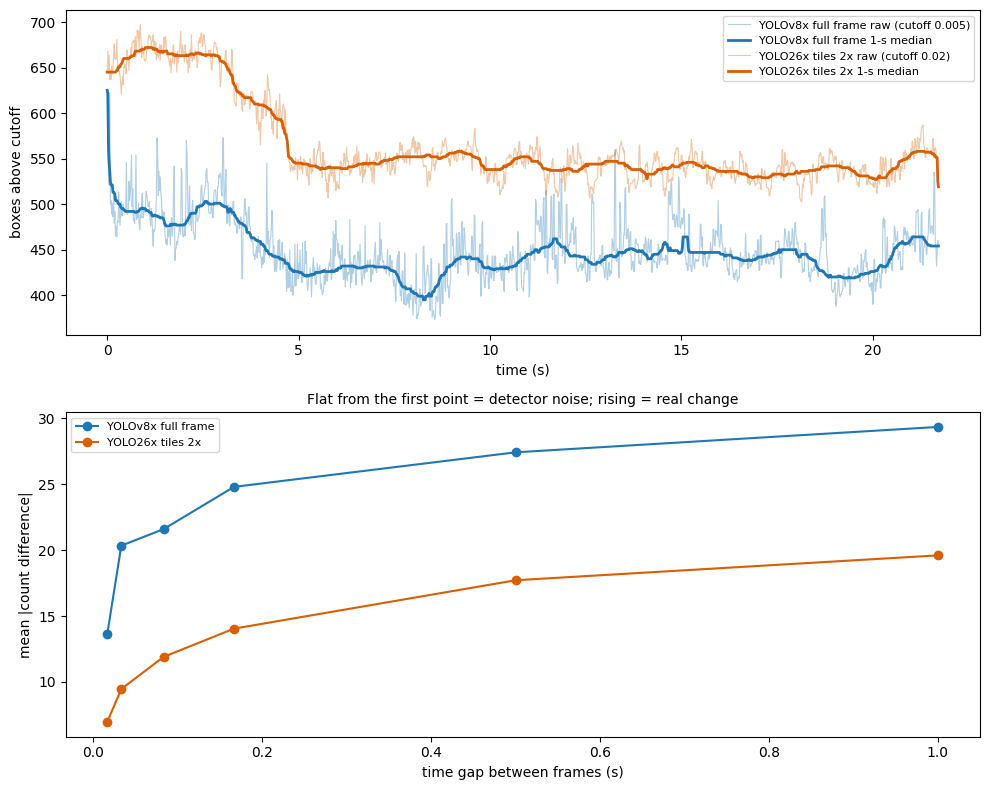

In [7]:
# ===== Cell 6: count stability (jitter) of both detectors over the full video =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# reload the saved runs (safe even after a kernel restart)
runA = load_run("yolov8x_full1920", OUT3)
runB = load_run("yolo26x_tiles640_1280", OUT3)
runs = {"YOLOv8x full frame": runA, "YOLO26x tiles 2x": runB}
FPS = info["fps"]

def counts_at(run, cutoff):
    """Boxes per frame with score >= cutoff, as an array aligned with run['frame_ids'] (sorted)."""
    idx = np.repeat(np.arange(len(run["frame_ids"])), run["counts"])
    keep = run["scores"] >= cutoff
    return np.bincount(idx[keep], minlength=len(run["frame_ids"])).astype(float)

def jitter_row(N, ks=(1, 3, 5, 10)):
    """Frame-to-frame change statistics of a count series: share of consecutive frame pairs whose
    count changes by at least k, plus the median and 95th percentile of |change|."""
    d = np.abs(np.diff(N))
    row = {f"frac|dN|>={k}": float((d >= k).mean()) for k in ks}
    row.update({"median|dN|": float(np.median(d)), "p95|dN|": float(np.percentile(d, 95))})
    return row

def smooth_1s(N, fps):
    """Running median over about one second (odd window), edges padded with the nearest value."""
    w = int(round(fps)) | 1
    return median_filter(N, size=w, mode="nearest")

def structure_function(N, lags):
    """Mean |N[t+k] - N[t]| for each lag k. Flat from k=1 = detector noise; growing with k = real change."""
    return np.array([np.abs(N[k:] - N[:-k]).mean() for k in lags])

def stability_report(runs, cutoffs, fps):
    """Jitter table for every (detector, cutoff), including the residual noise around the 1-s median.
    runs: {name: run}; cutoffs: {name: [cutoffs to try]}."""
    rows = []
    for name, run in runs.items():
        for c in cutoffs[name]:
            N = counts_at(run, c)
            res = N - smooth_1s(N, fps)
            rows.append(dict(detector=name, cutoff=c, mean_count=N.mean(), min_count=N.min(),
                             max_count=N.max(), residual_std=res.std(),
                             residual_std_pct=100 * res.std() / N.mean(), **jitter_row(N)))
    return pd.DataFrame(rows)

def plot_stability(runs, primary, fps, lags, path):
    """Two-panel figure: counts over time (raw + 1-s median) and the structure function per detector."""
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    colors = dict(zip(runs, ("#1f77b4", "#d95f02")))
    for name, run in runs.items():
        N = counts_at(run, primary[name]); t = np.arange(len(N)) / fps
        ax[0].plot(t, N, color=colors[name], alpha=0.35, lw=0.8, label=f"{name} raw (cutoff {primary[name]})")
        ax[0].plot(t, smooth_1s(N, fps), color=colors[name], lw=2, label=f"{name} 1-s median")
        ax[1].plot(np.array(lags) / fps, structure_function(N, lags), marker="o", color=colors[name], label=name)
    ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("boxes above cutoff"); ax[0].legend(fontsize=8)
    ax[1].set_xlabel("time gap between frames (s)"); ax[1].set_ylabel("mean |count difference|")
    ax[1].set_title("Flat from the first point = detector noise; rising = real change", fontsize=10)
    ax[1].legend(fontsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=130); plt.show()

CUTOFFS = {"YOLOv8x full frame": [0.003, 0.005, 0.01, 0.02],
           "YOLO26x tiles 2x": [0.01, 0.02, 0.05, 0.1]}
PRIMARY = {"YOLOv8x full frame": 0.005, "YOLO26x tiles 2x": 0.02}
LAGS = [1, 2, 5, 10, 30, 60]

rep = stability_report(runs, CUTOFFS, FPS)
rep.to_csv(OUT3 / "E003_stability_table.csv", index=False)
pd.set_option("display.width", 250)
print(rep.round(3).to_string(index=False))

print("\nmean |count difference| by frame gap (at the plotting cutoff):")
print(pd.DataFrame({n: structure_function(counts_at(r, PRIMARY[n]), LAGS)
                    for n, r in runs.items()}, index=[f"{k} frames" for k in LAGS]).round(2).to_string())

plot_stability(runs, PRIMARY, FPS, LAGS, OUT3 / "E003_stability.png")

## Cell 7 — Pack the detection results so we never have to re-run them

**In simple words:** the two detector runs took about an hour in total. Kaggle deletes the working files when the session ends, so we zip up the results now. Then you download the zip and upload it as a Kaggle Dataset. Every later notebook can use the boxes without repeating the detection.

**What goes in the zip:** the saved boxes and scores of both full-video runs (14 chunk files each), the stability table, and the stability picture. The 30-frame and 10-frame test files are left out.

**What you should see:** 14 chunk files for each run, and a zip of well under 200 MB.

In [8]:
# ===== Cell 7: zip the full-video detection results for download =====
import zipfile

def pack_results(out_dir, zip_path, tags):
    """Zip the shard files of the given run tags (plus the stability CSV/PNG) into one archive,
    checking that each run has exactly the expected number of shards. Returns the archive size in MB."""
    out_dir = Path(out_dir)
    files = []
    for tag in tags:
        parts = sorted(out_dir.glob(f"{tag}_part*.npz"))
        assert len(parts) == 14, f"{tag}: expected 14 shards for 1303 frames, found {len(parts)}"
        files += parts
    files += [out_dir / "E003_stability_table.csv", out_dir / "E003_stability.png"]
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_STORED) as z:   # npz files are already compressed
        for f in files:
            z.write(f, arcname=f.name)
    return Path(zip_path).stat().st_size / 1e6

size_mb = pack_results(OUT3, "/kaggle/working/e003_detections.zip",
                       ["yolov8x_full1920", "yolo26x_tiles640_1280"])
print(f"created e003_detections.zip: {size_mb:.0f} MB")

created e003_detections.zip: 88 MB


## Cell 8 — Does the "NMS-free" mode of YOLO26x make the count steadier?

**In simple words:** a detector often proposes several overlapping boxes for one person, and a clean-up step called NMS removes the extra ones. YOLO26 has an optional mode that skips that step (`nms=False`) and claims to give steadier results. We test that claim directly rather than assuming it.

**The test:** we run YOLO26x on the whole frame twice, once with the clean-up step (`nms=True`) and once without (`nms=False`), on all 1303 frames. Each run takes about 9 minutes. Nothing else changes between the two runs.

**A fair comparison:** the number of boxes depends on the confidence cutoff, and the flicker depends on the number of boxes. So for every detector (including the two runs from before) we pick the cutoff that gives the **same average count of about 450 boxes per frame**, and only then compare the flicker.

**What to look at:**
- `mean_count`: how close each detector got to the 450 target.
- `residual_std_pct`: the noise as a share of the count. Smaller is steadier.
- `frac|dN|>=5`: the share of neighbouring frames where the count jumps by 5 or more.

**If NMS-free is not clearly better:** that is a result too. It means the claim does not hold on our video.

In [9]:
# ===== Cell 8: NMS vs NMS-free (YOLO26x, whole frame) and a matched-count stability comparison =====
def detect_full_nms(model, img, nms_flag, imgsz=1920, conf=0.001, max_det=3000):
    """Whole-frame detection with the NMS setting pinned explicitly (nms=True: NMS on the one-to-many head;
    nms=False: NMS-free one-to-one head). Returns (boxes xyxy float32, scores float32)."""
    r = model.predict(img, imgsz=imgsz, classes=[0], conf=conf, max_det=max_det,
                      nms=nms_flag, verbose=False)[0]
    return r.boxes.xyxy.cpu().numpy().astype(np.float32), r.boxes.conf.cpu().numpy().astype(np.float32)

def cutoff_for_mean(run, target, grid=None):
    """Confidence cutoff whose mean boxes-per-frame is closest to `target` (searched on a log grid)."""
    grid = np.logspace(-3, np.log10(0.95), 120) if grid is None else grid
    means = np.array([counts_at(run, c).mean() for c in grid])
    return float(grid[np.argmin(np.abs(means - target))])

def matched_stability(runs, target, fps):
    """Stability table with every detector evaluated at the cutoff that gives ~`target` mean boxes per frame.
    Reports achieved mean count, noise around the 1-s median (% of count), and jump frequencies."""
    rows = []
    for name, run in runs.items():
        c = cutoff_for_mean(run, target)
        N = counts_at(run, c)
        res = N - smooth_1s(N, fps)
        rows.append(dict(detector=name, cutoff=round(c, 4), mean_count=N.mean(),
                         residual_std_pct=100 * res.std() / N.mean(), **jitter_row(N)))
    return pd.DataFrame(rows)

# run YOLO26x whole-frame twice (resumable; the first call of each setting is a warm-up)
modelC = YOLO("yolo26x.pt")
warm = read_frames(VIDEO, [0])[0]
for flag in (True, False):
    tag = f"yolo26x_full1920_nms{flag}"
    detect_full_nms(modelC, warm, flag)
    n_done = run_video(VIDEO, lambda img, f=flag: detect_full_nms(modelC, img, f), tag, OUT3, limit=None)
    assert n_done == info["n_decoded"], f"{tag}: processed {n_done} of {info['n_decoded']} frames"
    r = load_run(tag, OUT3)
    print(f"{tag}: boxes at floor 0.001: {r['counts'].min()}-{r['counts'].max()} per frame | "
          f"median {np.median(r['secs']):.3f} s/frame")

runs_all = {"YOLOv8x full frame": runA,
            "YOLO26x full frame, nms=True": load_run("yolo26x_full1920_nmsTrue", OUT3),
            "YOLO26x full frame, nms=False": load_run("yolo26x_full1920_nmsFalse", OUT3),
            "YOLO26x tiles 2x": runB}
match = matched_stability(runs_all, target=450, fps=FPS)
match.to_csv(OUT3 / "E003_matched_stability.csv", index=False)
pd.set_option("display.width", 250)
print(match.round(3).to_string(index=False))

yolo26x_full1920_nmsTrue: boxes at floor 0.001: 1464-1889 per frame | median 0.393 s/frame
yolo26x_full1920_nmsFalse: boxes at floor 0.001: 1359-1799 per frame | median 0.392 s/frame
                     detector  cutoff  mean_count  residual_std_pct  frac|dN|>=1  frac|dN|>=3  frac|dN|>=5  frac|dN|>=10  median|dN|  p95|dN|
           YOLOv8x full frame   0.005     449.369             5.014        0.939        0.737        0.606         0.422         7.0    52.95
 YOLO26x full frame, nms=True   0.018     450.517             2.423        0.909        0.607        0.460         0.250         4.0    19.95
YOLO26x full frame, nms=False   0.017     447.972             2.375        0.924        0.662        0.495         0.262         4.0    19.00
             YOLO26x tiles 2x   0.032     444.299             2.282        0.908        0.616        0.451         0.218         4.0    17.00


## Cell 9 — Steadiness at each detector's best setting, and near vs far

**In simple words:** in Cell 8 we compared the detectors at the same average box count. That is fair in one way but not in another, because each detector normally runs at its own best confidence cutoff. Here we look at both ways.

**What this cell does:**
1. **Finds each detector's best cutoff** using the 5 tuning frames we labelled by hand (the same rule as E002: best balance of missed and false boxes), using the boxes already saved from the full video.
2. **Checks accuracy at that cutoff** on the other 10 labelled frames, so steadiness and accuracy sit side by side.
3. **Measures the flicker at that cutoff**, and again at three different box counts (350, 450 and 550) to see whether the ranking depends on the count.
4. **Splits the flicker into the far half and the near half** of the picture. Far people are small and hard, so we expect them to flicker more, and we check whether that is true.

**How to read it:** a detector that is both accurate and steady is the one we want for the crowd masks and the counts. If the ranking changes between the views, we report that too.

In [10]:
# ===== Cell 9: stability at each detector's F1-optimal cutoff, count-matched robustness, near/far split =====
from src.data.via import load_ground_truth
from src.evaluation.detection import eval_frame, summarise

pts, ign, _ = load_ground_truth(REPO_DIR / "data/your_video")
SHAPE = (1920, 1080)
far_y = SHAPE[0] / 2
ids = sorted(int(i) for i in pts.frame_id.unique())
tune_ids = ids[1::3]                                   # the 5 tuning frames (same rule as E002)
test_ids = [i for i in ids if i not in tune_ids]       # the 10 reporting frames
GRID = [0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7, 0.9]

def boxes_for(run, fid):
    """Boxes and scores of one video frame from a saved run (frame_ids must be 0..N-1 in order)."""
    off = np.concatenate([[0], np.cumsum(run["counts"])])
    i = int(np.searchsorted(run["frame_ids"], fid))
    assert run["frame_ids"][i] == fid
    return run["boxes"][off[i]:off[i + 1]], run["scores"][off[i]:off[i + 1]]

def rows_for_run(run, fids, thr):
    """One metrics row per labelled frame at confidence cutoff thr (same scoring as E002)."""
    return pd.DataFrame([dict(frame_id=i, **eval_frame(
        pts[pts.frame_id == i][["x", "y"]].to_numpy(float), *boxes_for(run, i),
        ign[ign.frame_id == i]["vertices"].tolist(), thr, far_y)) for i in fids])

def best_f1_cutoff(run):
    """Cutoff with the best F1 on the tuning frames."""
    return max(GRID, key=lambda t: summarise(rows_for_run(run, tune_ids, t))["F1"])

def counts_region(run, cutoff, far):
    """Per-frame box counts above cutoff, counting only boxes whose head anchor (centre x, top+15% h)
    lies in the far half (y < far_y) if far=True, else in the near half."""
    b = run["boxes"]; hy = b[:, 1] + 0.15 * (b[:, 3] - b[:, 1])
    idx = np.repeat(np.arange(len(run["frame_ids"])), run["counts"])
    keep = (run["scores"] >= cutoff) & ((hy < far_y) if far else (hy >= far_y))
    return np.bincount(idx[keep], minlength=len(run["frame_ids"])).astype(float)

# 1) best cutoff per detector, tuned on the 5 tuning frames
cut = {n: best_f1_cutoff(r) for n, r in runs_all.items()}

# 2) accuracy of each detector at its best cutoff, on the 10 test frames
acc = []
for n, r in runs_all.items():
    S = summarise(rows_for_run(r, test_ids, cut[n]))
    acc.append(dict(detector=n, cutoff=cut[n], MAE=S["MAE"], bias=S["bias"], precision=S["precision"],
                    recall=S["recall"], recall_far=S["recall_far"]))
print("ACCURACY at the F1-optimal cutoff (10 test frames)")
print(pd.DataFrame(acc).round(3).to_string(index=False))

# 3) steadiness at the same cutoffs (whole video)
print("\nSTEADINESS at the F1-optimal cutoff (all 1303 frames)")
stab = stability_report(runs_all, {n: [cut[n]] for n in runs_all}, FPS)
print(stab.round(3).to_string(index=False))

# 4) robustness: steadiness at matched average counts of 350, 450 and 550 boxes per frame
print("\nSTEADINESS at matched average counts")
for target in (350, 450, 550):
    m = matched_stability(runs_all, target, FPS)
    m.insert(0, "target", target)
    print(m[["target", "detector", "cutoff", "mean_count", "residual_std_pct", "frac|dN|>=5"]]
          .round(3).to_string(index=False))

# 5) far half vs near half at the F1-optimal cutoff: absolute noise (boxes) AND percent of that half's count
print("\nFAR vs NEAR half: mean count, absolute noise around the 1-s median (boxes), noise as % of the half's count")
rows = []
for n, r in runs_all.items():
    row = dict(detector=n)
    for label, far in (("far", True), ("near", False)):
        N = counts_region(r, cut[n], far)
        res = N - smooth_1s(N, FPS)
        row[f"{label}_mean"] = N.mean()
        row[f"{label}_std"] = res.std()                       # absolute flicker in boxes: comparable across halves
        row[f"{label}_noise_pct"] = 100 * res.std() / N.mean()  # depends on the half's size, read with care
    row["far_share_of_boxes_%"] = 100 * row["far_mean"] / (row["far_mean"] + row["near_mean"])
    rows.append(row)
print(pd.DataFrame(rows).round(2).to_string(index=False))

ACCURACY at the F1-optimal cutoff (10 test frames)
                     detector  cutoff  MAE  bias  precision  recall  recall_far
           YOLOv8x full frame   0.005 23.5  -5.3      0.674   0.666       0.391
 YOLO26x full frame, nms=True   0.020 43.7 -42.5      0.770   0.698       0.467
YOLO26x full frame, nms=False   0.010 87.6  87.6      0.654   0.779       0.597
             YOLO26x tiles 2x   0.030 31.8 -31.4      0.762   0.710       0.523

STEADINESS at the F1-optimal cutoff (all 1303 frames)
                     detector  cutoff  mean_count  min_count  max_count  residual_std  residual_std_pct  frac|dN|>=1  frac|dN|>=3  frac|dN|>=5  frac|dN|>=10  median|dN|  p95|dN|
           YOLOv8x full frame   0.005     450.262      373.0      625.0        22.506             4.998        0.942        0.741        0.608         0.422         7.0    52.00
 YOLO26x full frame, nms=True   0.020     425.437      389.0      470.0        10.231             2.405        0.895        0.621        0

## Cell 10 — Who finds the most people when they all make the same share of mistakes?

**In simple words:** a detector can look better just by accepting more uncertain boxes, which finds more people but also makes more false alarms. To compare fairly, we compare the detectors at the **same precision** (the share of their boxes that are real people).

**Two fair ways of doing it:**
1. **Read the accuracy curve (main answer).** For every detector we sweep the cutoff over the 10 test frames and ask: at 65%, 70% and 76% precision, what is the most people it can find? This compares the detectors themselves. It is not a setting you could deploy, because it is chosen using the test frames.
2. **Pick the cutoff on the 5 tuning frames** and check what precision it really gives on the test frames. That is what would happen in real use. If the precision drifts by more than 0.02 from the target, the row is not a fair comparison.

**Also printed:** how many of the labelled test people are in the far half, so we know how much to trust the far-half numbers.

**How to read it:** with only 10 frames, differences of about 3 points or less are within noise. We look for large, consistent differences across the three precision levels.

In [11]:
# ===== Cell 10: accuracy at MATCHED PRECISION (PR-curve reading + threshold-transfer check) =====
from scipy.ndimage import median_filter

FINE = np.logspace(np.log10(0.001), np.log10(0.9), 60)     # constant 12% steps: dense where cutoffs actually sit

def pr_curve(run, fids):
    """Pooled precision / recall / far-recall / MAE / bias of one detector over `fids`, at every cutoff of FINE."""
    rows = []
    for t in FINE:
        r = rows_for_run(run, fids, t)
        d = r["n_det"] - r["n_true"]
        rows.append(dict(cutoff=t, precision=r["tp"].sum() / max(r["n_det"].sum(), 1),
                         recall=r["tp"].sum() / r["n_true"].sum(), recall_far=r["tp_far"].sum() / r["n_far"].sum(),
                         MAE=d.abs().mean(), bias=d.mean(), n_true=r["n_true"].sum(), n_far=r["n_far"].sum()))
    return pd.DataFrame(rows)

def recall_at_precision(curve, target):
    """Best recall reachable while precision >= target (standard 'interpolated' reading of a PR curve).
    Returns the curve row that achieves it, or None if the target precision is never reached."""
    ok = curve[curve["precision"] >= target]
    return None if ok.empty else ok.loc[ok["recall"].idxmax()]

def transfer_cutoff(tune_curve, target, win=5):
    """Cutoff whose SMOOTHED tuning-frame precision is closest to target (running median over `win`
    neighbouring cutoffs damps single-box spikes on the 5 tuning frames)."""
    sm = median_filter(tune_curve["precision"].to_numpy(), size=win, mode="nearest")
    return float(tune_curve["cutoff"].iloc[int(np.argmin(np.abs(sm - target)))])

TARGETS = (0.65, 0.70, 0.76)
test_curves = {n: pr_curve(r, test_ids) for n, r in runs_all.items()}
tune_curves = {n: pr_curve(r, tune_ids) for n, r in runs_all.items()}

c0 = next(iter(test_curves.values()))
print(f"labelled heads in the 10 test frames: {int(c0.n_true.iloc[0])}; far half (y < {far_y:.0f}): "
      f"{int(c0.n_far.iloc[0])} ({100 * c0.n_far.iloc[0] / c0.n_true.iloc[0]:.0f}%)")

# Lens A: recall reachable at each precision level, read from the test-frame PR curve
A = []
for target in TARGETS:
    for n in runs_all:
        b = recall_at_precision(test_curves[n], target)
        A.append(dict(target_prec=target, detector=n, cutoff=None if b is None else round(b.cutoff, 4),
                      precision=None if b is None else b.precision, recall=None if b is None else b.recall,
                      recall_far=None if b is None else b.recall_far))
A = pd.DataFrame(A)
A.to_csv(OUT3 / "E003_recall_at_precision.csv", index=False)
print("\nLENS A: best recall reachable at each precision level (10 test frames; a curve comparison)")
print(A.round(3).to_string(index=False))

# Lens B: cutoff picked on the tuning frames, then checked on the test frames
B = []
for target in TARGETS:
    for n in runs_all:
        t = transfer_cutoff(tune_curves[n], target)
        row = test_curves[n].iloc[int(np.argmin(np.abs(test_curves[n]["cutoff"] - t)))]
        B.append(dict(target_prec=target, detector=n, cutoff=round(t, 4), test_precision=row.precision,
                      recall=row.recall, recall_far=row.recall_far, MAE=row.MAE, bias=row.bias,
                      precision_ok=abs(row.precision - target) <= 0.02))
B = pd.DataFrame(B)
B.to_csv(OUT3 / "E003_matched_precision_transfer.csv", index=False)
print("\nLENS B: cutoff chosen on the 5 tuning frames, checked on the 10 test frames")
print(B.round(3).to_string(index=False))

labelled heads in the 10 test frames: 4582; far half (y < 960): 1391 (30%)

LENS A: best recall reachable at each precision level (10 test frames; a curve comparison)
 target_prec                      detector  cutoff  precision  recall  recall_far
        0.65            YOLOv8x full frame   0.004      0.655   0.683       0.418
        0.65  YOLO26x full frame, nms=True   0.011      0.670   0.794       0.612
        0.65 YOLO26x full frame, nms=False   0.010      0.654   0.779       0.597
        0.65              YOLO26x tiles 2x   0.016      0.658   0.806       0.650
        0.70            YOLOv8x full frame   0.006      0.708   0.622       0.342
        0.70  YOLO26x full frame, nms=True   0.014      0.710   0.756       0.553
        0.70 YOLO26x full frame, nms=False   0.014      0.705   0.722       0.512
        0.70              YOLO26x tiles 2x   0.020      0.700   0.775       0.607
        0.76            YOLOv8x full frame   0.010      0.773   0.533       0.240
        0.76 

## Cell 12 — See what the detectors actually see (one labelled frame)

**In simple words:** so far we looked at numbers. Here we look at the picture. We take one frame where we clicked every head by hand, and draw what each of the four detectors found on it.

**How to read the picture:**
- **Yellow dots** are the heads we clicked by hand (our ground truth).
- **Coloured boxes** are what the detector found.
- **A yellow dot with no box around it** is a person the detector missed.
- **A box with no yellow dot** is either a false alarm or a real person we did not click. Remember that our clicks are a lower bound, so not every such box is a mistake.
- **Red dashed lines** mark the areas we told the scoring to ignore.

**Two rows:** the top row shows the whole frame. The bottom row zooms into the far crowd, the most crowded corner of the far half, where the difference between detectors is largest.

**Fair setting:** every detector uses the cutoff that gives about 70% precision, so none of them is favoured. The title of each panel says how many boxes it drew and how many labelled heads it found.

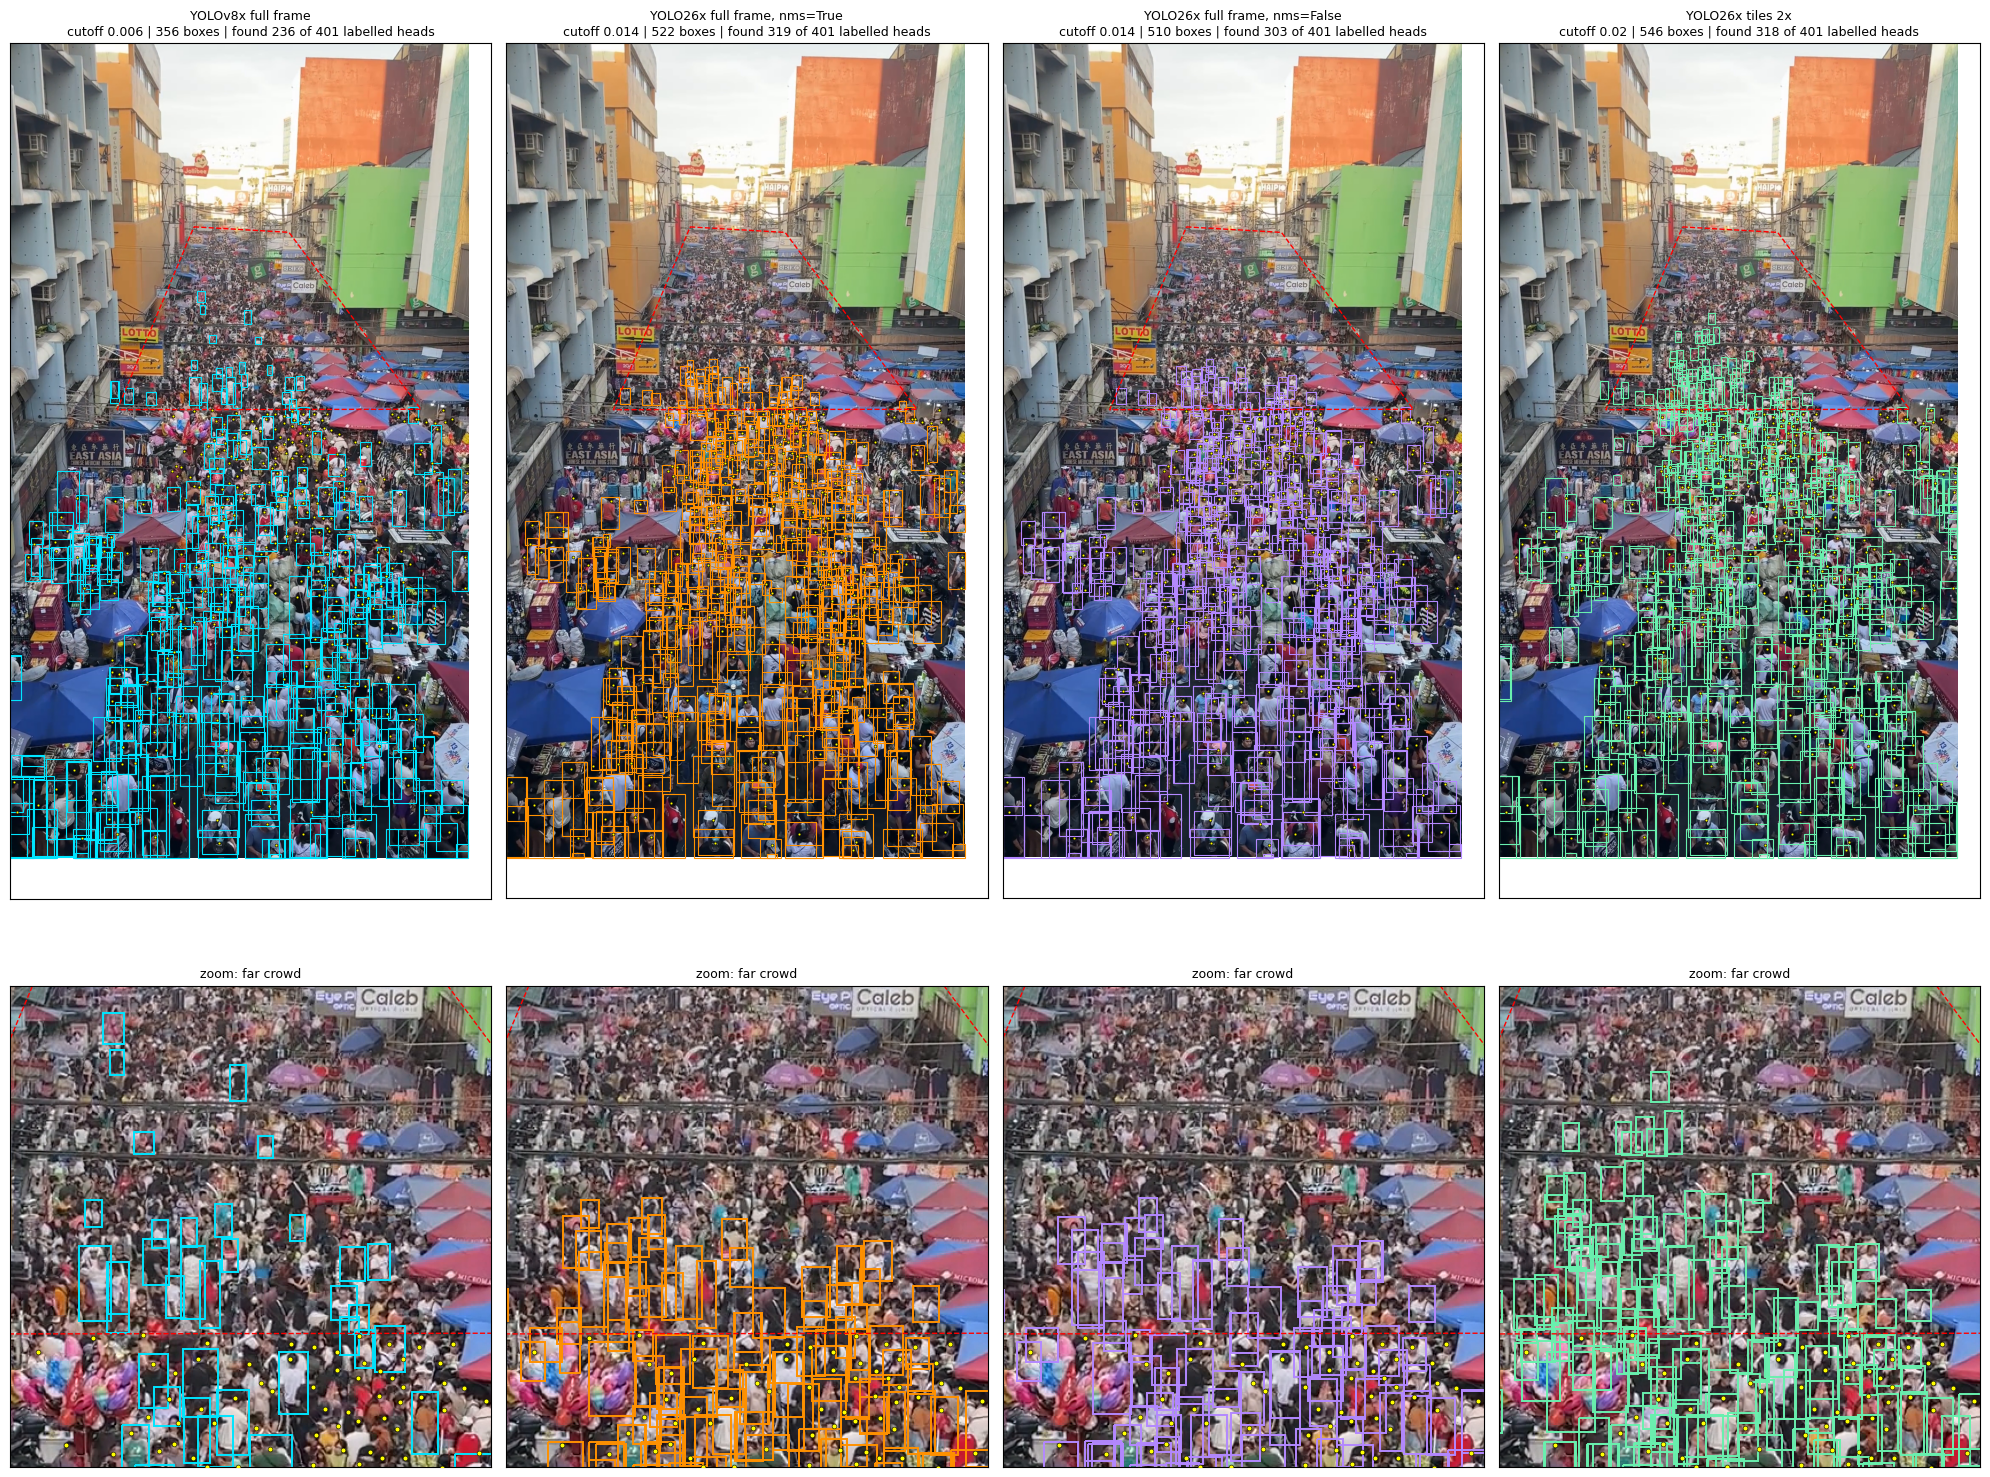

In [12]:
# ===== Cell 12: draw the four detectors' boxes on one labelled frame =====
import cv2
import matplotlib.pyplot as plt

FRAME = 465                                     # any labelled frame id (0, 93, 186, ... 1302)
assert FRAME in ids, f"{FRAME} is not a labelled frame; choose one of {ids}"
CUTS = {"YOLOv8x full frame": 0.006, "YOLO26x full frame, nms=True": 0.014,
        "YOLO26x full frame, nms=False": 0.014, "YOLO26x tiles 2x": 0.020}   # ~70% precision (Cell 10, Lens A)
COLORS = ["#00e5ff", "#ff9100", "#b388ff", "#69f0ae"]

def densest_window(xy, size=420, y_max=None):
    """Top-left corner (x0, y0) of the size x size window containing the most points of xy (optionally only y < y_max)."""
    p = xy if y_max is None else xy[xy[:, 1] < y_max]
    best, arg = -1, (0, 0)
    for x0 in range(0, 1080 - size + 1, 40):
        for y0 in range(0, 1920 - size + 1, 40):
            n = ((p[:, 0] >= x0) & (p[:, 0] < x0 + size) & (p[:, 1] >= y0) & (p[:, 1] < y0 + size)).sum()
            if n > best:
                best, arg = n, (x0, y0)
    return arg

def draw_panel(ax, img_rgb, boxes, scores, cutoff, gt_xy, polys, title, color, box=None, lw=0.8):
    """Draw one detector's boxes (score >= cutoff), the labelled heads (yellow dots) and the ignore areas (red dashed).
    box=(x0, y0, size) zooms into a window."""
    ax.imshow(img_rgb)
    keep = scores >= cutoff
    for x1, y1, x2, y2 in boxes[keep]:
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=color, lw=lw))
    ax.scatter(gt_xy[:, 0], gt_xy[:, 1], s=12 if box else 4, c="yellow", edgecolors="black",
               linewidths=0.4, zorder=5)
    for poly in polys:
        p = np.asarray(poly, float); ax.plot(*np.vstack([p, p[:1]]).T, "r--", lw=1)
    if box:
        x0, y0, s = box; ax.set_xlim(x0, x0 + s); ax.set_ylim(y0 + s, y0)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

img = cv2.cvtColor(read_frames(VIDEO, [FRAME])[FRAME], cv2.COLOR_BGR2RGB)
gt = pts[pts.frame_id == FRAME][["x", "y"]].to_numpy(float)
polys = ign[ign.frame_id == FRAME]["vertices"].tolist()
x0, y0 = densest_window(gt, 420, far_y)          # crowded corner of the far half

fig, axs = plt.subplots(2, 4, figsize=(20, 16), gridspec_kw={"height_ratios": [2, 1.05]})
for j, (name, run) in enumerate(runs_all.items()):
    b, s = boxes_for(run, FRAME); c = CUTS[name]
    r = rows_for_run(run, [FRAME], c).iloc[0]
    title = f"{name}\ncutoff {c} | {int((s >= c).sum())} boxes | found {int(r.tp)} of {int(r.n_true)} labelled heads"
    draw_panel(axs[0, j], img, b, s, c, gt, polys, title, COLORS[j])
    draw_panel(axs[1, j], img, b, s, c, gt, polys, "zoom: far crowd", COLORS[j], box=(x0, y0, 420), lw=1.4)
fig.tight_layout()
fig.savefig(OUT3 / f"E003_example_frame{FRAME}.png", dpi=110)
plt.show()

## Cell 11 — Pack all four full-video runs for the next notebooks

**In simple words:** we now have boxes for all 1303 frames from four detector settings, plus the tables that compare them. This cell zips everything so we can upload it once as a Kaggle Dataset. The next notebook (camera registration) uses the boxes to draw crowd masks, so it does not have to repeat the hour of detection.

**It also saves a small note (`E003_decisions.json`)** that records which boxes and cutoff the next notebook should try for the crowd masks. Two options are listed, and the registration notebook decides between them by measuring the camera-tracking error with each.

**What you should see:** the expected number of chunk files for each of the four runs (worked out from the video length, so no number is typed in by hand), and a zip of about 100–200 MB. This zip replaces the earlier one, so you can skip uploading that one.

In [13]:
# ===== Cell 11: pack all four full-video runs, tables and the mask ablation plan for download =====
import inspect, json, zipfile

TAGS = ["yolov8x_full1920", "yolo26x_full1920_nmsTrue", "yolo26x_full1920_nmsFalse", "yolo26x_tiles640_1280"]
TABLES = ["E003_stability_table.csv", "E003_stability.png", "E003_matched_stability.csv",
          "E003_recall_at_precision.csv", "E003_matched_precision_transfer.csv"]

def expected_shards(n_frames, shard):
    """Number of chunk files a run of n_frames frames produces with `shard` frames per chunk."""
    return int(np.ceil(n_frames / shard))

def write_decisions(path):
    """Record the two candidate crowd-mask sources from E003; notebook 05 decides between them by registration drift."""
    dec = {"candidates": [
               {"source": "yolo26x_tiles640_1280", "cutoff": 0.016, "cost_s_per_frame": 2.36,
                "note": "best recall (0.81) and far recall (0.65) at precision ~0.66"},
               {"source": "yolo26x_full1920_nmsTrue", "cutoff": 0.011, "cost_s_per_frame": 0.39,
                "note": "recall 0.79, far recall 0.61 at precision ~0.67; 6x cheaper"}],
           "decision_rule": "run the registration drift check with both masks; if the drift is the same, use the cheaper one",
           "note": "10 labelled test frames from one clip"}
    Path(path).write_text(json.dumps(dec, indent=2))

def pack_all(out_dir, zip_path, tags, tables, n_frames, shard):
    """Zip the shards of every tag, the comparison tables and the decisions file; returns the size in MB."""
    out_dir = Path(out_dir)
    write_decisions(out_dir / "E003_decisions.json")
    want = expected_shards(n_frames, shard)
    files = []
    for tag in tags:
        parts = sorted(out_dir.glob(f"{tag}_part*.npz"))
        assert len(parts) == want, f"{tag}: expected {want} shards for {n_frames} frames, found {len(parts)}"
        files += parts
    for t in tables + ["E003_decisions.json"]:
        assert (out_dir / t).exists(), f"missing {t} (run the earlier cells first)"
        files.append(out_dir / t)
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_STORED) as z:      # npz files are already compressed
        for f in files:
            z.write(f, arcname=f.name)
    return Path(zip_path).stat().st_size / 1e6

SHARD = inspect.signature(run_video).parameters["shard"].default       # the chunk size used in Cell 4
size_mb = pack_all(OUT3, "/kaggle/working/e003_detections_all.zip", TAGS, TABLES, info["n_decoded"], SHARD)
print(f"created e003_detections_all.zip: {size_mb:.0f} MB")

created e003_detections_all.zip: 161 MB
